# Protein Sequence Models: PFAM Family Classification (Top-10)

This notebook trains a **sequence-only CNN** classifier to predict **Pfam family** from protein sequences.

**Task**
- Multi-class classification: top-10 Pfam families
- Dataset: `data/processed/protein_uniprot_pfam_top10_per400.csv`
- Labels: Pfam family IDs (e.g., `PF00001`, ...)

**Model**
- Token embedding over amino acids (including padding/unknown)
- 1D CNN with multiple kernel sizes (3/5/7)
- Global max pooling
- MLP classification head

**Outputs**
- Trained model: `models/protein/sequence_cnn/cnn_top10_per400.pt`
- Figures:
  - `reports/figures/protein_seq_cnn_loss_top10_per400.png`
  - `reports/figures/protein_seq_cnn_acc_top10_per400.png`
  - `reports/figures/cm_protein_seq_cnn_top10_per400.png`
- Test results CSV: `reports/protein_seq_cnn_test_results_top10_per400.csv`
- Summary JSON: `reports/protein_seq_cnn_summary_top10_per400.json`

In [1]:
from pathlib import Path
import json
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix

# -----------------------------
# Paths + reproducibility
# -----------------------------
ROOT = Path.cwd().parents[0]
DATA = ROOT / "data"
PROCESSED = DATA / "processed"
REPORTS = ROOT / "reports"
FIGURES = REPORTS / "figures"
MODELS = ROOT / "models"

for p in [REPORTS, FIGURES, MODELS]:
    p.mkdir(parents=True, exist_ok=True)

MODEL_DIR = MODELS / "protein" / "sequence_cnn"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cpu'

## Load dataset

We load the processed top-10 Pfam dataset and run basic sanity checks:
- no missing sequences
- only canonical amino acids
- label distribution looks reasonable

In [2]:
csv_path = PROCESSED / "protein_uniprot_pfam_top10_per400.csv"
assert csv_path.exists(), f"Missing dataset: {csv_path}"

df = pd.read_csv(csv_path)
df.shape, df.head(3)

((2293, 4),
   accession                                           sequence  length  \
 0    Q96RD1  MRNHTEITEFILLGLTDDPNFQVVIFVFLLITYMLSITGNLTLITI...     312   
 1    Q9H210  MRQINQTQVTEFLLLGLSDGPHTEQLLFIVLLGVYLVTVLGNLLLI...     308   
 2    Q8NGZ3  MNHSVVTEFIILGLTKKPELQGIIFLFFLIVYLVAFLGNMLIIIAK...     307   
 
     family  
 0  PF13853  
 1  PF13853  
 2  PF13853  )

In [3]:
# Basic checks
na_counts = df[["accession", "sequence", "length", "family"]].isna().sum()
dup_accessions = int(df["accession"].duplicated().sum())
dup_seq_family = int(df.duplicated(subset=["sequence", "family"]).sum())

# canonical AA set
AA_CANON = set("ACDEFGHIKLMNPQRSTVWY")  # 20 standard
noncanon = df["sequence"].apply(lambda s: any(ch not in AA_CANON for ch in s))
n_noncanon = int(noncanon.sum())

len_mismatch = int((df["sequence"].str.len() != df["length"]).sum())

print("NA counts:\n", na_counts)
print("\nDuplicates:", {"dup_accessions": dup_accessions, "dup_seq_family": dup_seq_family})
print("Length mismatches:", len_mismatch)
print("Sequences with noncanonical chars:", n_noncanon)

# label summary
le = LabelEncoder()
y = le.fit_transform(df["family"].astype(str))
classes = le.classes_
counts = np.bincount(y)

print("\nK:", len(classes))
print("Classes:", list(classes))
print("Counts per class:", counts)

NA counts:
 accession    0
sequence     0
length       0
family       0
dtype: int64

Duplicates: {'dup_accessions': 0, 'dup_seq_family': 0}
Length mismatches: 0
Sequences with noncanonical chars: 0

K: 10
Classes: ['PF00001', 'PF00046', 'PF00069', 'PF00071', 'PF00076', 'PF00096', 'PF01352', 'PF07686', 'PF12796', 'PF13853']
Counts per class: [287 187 203 125 121 194 350 309 117 400]


## Train/Val/Test split

We use stratified splitting so each Pfam class is represented similarly in:
- Train
- Validation
- Test

Split proportions:
- Train: 70%
- Validation: 15%
- Test: 15%

In [4]:
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=SEED, stratify=df["family"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED, stratify=temp_df["family"]
)

print("Train/Val/Test:", train_df.shape, val_df.shape, test_df.shape)

def label_counts(sub):
    return np.bincount(le.transform(sub["family"]), minlength=len(classes))

print("\nTrain label counts:", label_counts(train_df))
print("Val label counts:", label_counts(val_df))
print("Test label counts:", label_counts(test_df))

Train/Val/Test: (1605, 4) (344, 4) (344, 4)

Train label counts: [201 131 142  87  85 136 245 216  82 280]
Val label counts: [43 28 30 19 18 29 53 46 18 60]
Test label counts: [43 28 31 19 18 29 52 47 17 60]


## Tokenization (amino acids → integer IDs)

We map:
- 20 canonical amino acids → 1..20
- 0 reserved for padding
- unknown AA (shouldn't happen after validation) → 20 (or separate token if desired)

We also pad/truncate sequences to a fixed max length:
- `MAX_LEN = 512`

In [5]:
AA_LIST = list("ACDEFGHIKLMNPQRSTVWY")
AA_TO_ID = {aa: i+1 for i, aa in enumerate(AA_LIST)}  # 1..20
PAD_ID = 0
UNK_ID = len(AA_LIST)  # 20 (rare, but safe fallback)

MAX_LEN = 512

def encode_sequence(seq: str, max_len: int = MAX_LEN):
    ids = [AA_TO_ID.get(ch, UNK_ID) for ch in seq]
    if len(ids) >= max_len:
        ids = ids[:max_len]
    else:
        ids = ids + [PAD_ID] * (max_len - len(ids))
    return np.array(ids, dtype=np.int64)

# quick sanity
ex = df.iloc[0]["sequence"]
enc = encode_sequence(ex)
enc.shape, enc[:12], len(ex)

((512,), array([11, 15, 12,  7, 17,  4,  8, 17,  4,  5,  8, 10]), 312)

## Dataset + DataLoaders

We create a PyTorch `Dataset` that returns:
- `input_ids`: (MAX_LEN,)
- `label`: integer class index

Then we build loaders for train/val/test.

In [6]:
class ProteinSeqDataset(Dataset):
    def __init__(self, frame: pd.DataFrame):
        self.frame = frame.reset_index(drop=True)

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        x = encode_sequence(row["sequence"], MAX_LEN)
        y = le.transform([row["family"]])[0]
        return torch.tensor(x, dtype=torch.long), torch.tensor(y, dtype=torch.long)

BATCH_SIZE = 64

train_loader = DataLoader(ProteinSeqDataset(train_df), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(ProteinSeqDataset(val_df), batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(ProteinSeqDataset(test_df), batch_size=BATCH_SIZE, shuffle=False)

(len(train_loader.dataset), len(val_loader.dataset), len(test_loader.dataset)), DEVICE

((1605, 344, 344), 'cpu')

## Sequence CNN model

Architecture:
- Embedding layer (vocab_size = 21 including PAD)
- 3 convolution branches (kernel sizes: 3, 5, 7)
- Global max pooling for each branch → concatenated vector
- MLP head → logits over `K` classes

In [7]:
class CNNProteinClassifier(nn.Module):
    def __init__(self, vocab_size: int, emb_dim: int, n_classes: int, dropout: float = 0.25):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_ID)

        self.conv3 = nn.Conv1d(emb_dim, 128, kernel_size=3, padding=1)
        self.conv5 = nn.Conv1d(emb_dim, 128, kernel_size=5, padding=2)
        self.conv7 = nn.Conv1d(emb_dim, 128, kernel_size=7, padding=3)

        self.dropout = nn.Dropout(dropout)
        self.head = nn.Sequential(
            nn.Linear(128*3, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, n_classes)
        )

    def forward(self, x_ids):
        # x_ids: (B, L)
        x = self.embed(x_ids)              # (B, L, E)
        x = x.transpose(1, 2)              # (B, E, L)

        c3 = torch.relu(self.conv3(x))     # (B, 128, L)
        c5 = torch.relu(self.conv5(x))     # (B, 128, L)
        c7 = torch.relu(self.conv7(x))     # (B, 128, L)

        p3 = torch.max(c3, dim=2).values   # (B, 128)
        p5 = torch.max(c5, dim=2).values
        p7 = torch.max(c7, dim=2).values

        feats = torch.cat([p3, p5, p7], dim=1)  # (B, 384)
        feats = self.dropout(feats)
        logits = self.head(feats)              # (B, K)
        return logits

K = len(classes)
VOCAB_SIZE = len(AA_LIST) + 1  # 20 AAs + PAD(0)

model = CNNProteinClassifier(vocab_size=VOCAB_SIZE, emb_dim=32, n_classes=K, dropout=0.25).to(DEVICE)
model

CNNProteinClassifier(
  (embed): Embedding(21, 32, padding_idx=0)
  (conv3): Conv1d(32, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (conv5): Conv1d(32, 128, kernel_size=(5,), stride=(1,), padding=(2,))
  (conv7): Conv1d(32, 128, kernel_size=(7,), stride=(1,), padding=(3,))
  (dropout): Dropout(p=0.25, inplace=False)
  (head): Sequential(
    (0): Linear(in_features=384, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.25, inplace=False)
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)

## Training loop

We train using:
- CrossEntropyLoss
- Adam optimizer
- Early stopping based on **validation accuracy**
- Save best model checkpoint

In [8]:
def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_correct = 0
    total = 0

    loss_fn = nn.CrossEntropyLoss()

    for xb, yb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        if is_train:
            optimizer.zero_grad()

        logits = model(xb)
        loss = loss_fn(logits, yb)

        if is_train:
            loss.backward()
            optimizer.step()

        total_loss += float(loss.item()) * xb.size(0)
        preds = torch.argmax(logits, dim=1)
        total_correct += int((preds == yb).sum().item())
        total += xb.size(0)

    return total_loss / total, total_correct / total

In [9]:
LR = 1e-3
EPOCHS = 12
PATIENCE = 3

optimizer = torch.optim.Adam(model.parameters(), lr=LR)

history = []
best_val_acc = -1.0
best_path = MODEL_DIR / "cnn_top10_per400.pt"
pat = 0

t0 = time.time()
for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(model, train_loader, optimizer=optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, optimizer=None)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc
    })

    print(pd.DataFrame([history[-1]]))

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_path)
        pat = 0
    else:
        pat += 1
        if pat >= PATIENCE:
            print(f"Early stopping at epoch {epoch}. Best val_acc={best_val_acc:.4f}")
            break

print(f"Best val_acc: {best_val_acc:.4f}")
best_val_acc, best_path

   epoch  train_loss  train_acc  val_loss   val_acc
0      1    2.190721    0.23053  1.961784  0.369186
   epoch  train_loss  train_acc  val_loss   val_acc
0      2    1.795985   0.411215  1.446582  0.456395
   epoch  train_loss  train_acc  val_loss   val_acc
0      3    1.367157    0.53271  1.087562  0.656977
   epoch  train_loss  train_acc  val_loss   val_acc
0      4    1.115755   0.626168  0.836733  0.822674
   epoch  train_loss  train_acc  val_loss   val_acc
0      5    0.846767   0.720872  0.668678  0.741279
   epoch  train_loss  train_acc  val_loss  val_acc
0      6    0.720262   0.755763  0.498762    0.875
   epoch  train_loss  train_acc  val_loss   val_acc
0      7    0.609374        0.8  0.405924  0.886628
   epoch  train_loss  train_acc  val_loss   val_acc
0      8    0.501285   0.847352  0.291401  0.950581
   epoch  train_loss  train_acc  val_loss   val_acc
0      9    0.413197   0.872897  0.270491  0.936047
   epoch  train_loss  train_acc  val_loss   val_acc
0     10     0

(0.9505813953488372,
 PosixPath('/Users/saturnine/Projects/bio-seq-lm-capstone/models/protein/sequence_cnn/cnn_top10_per400.pt'))

## Training curves

We save:
- loss curves (train vs val)
- accuracy curves (train vs val)

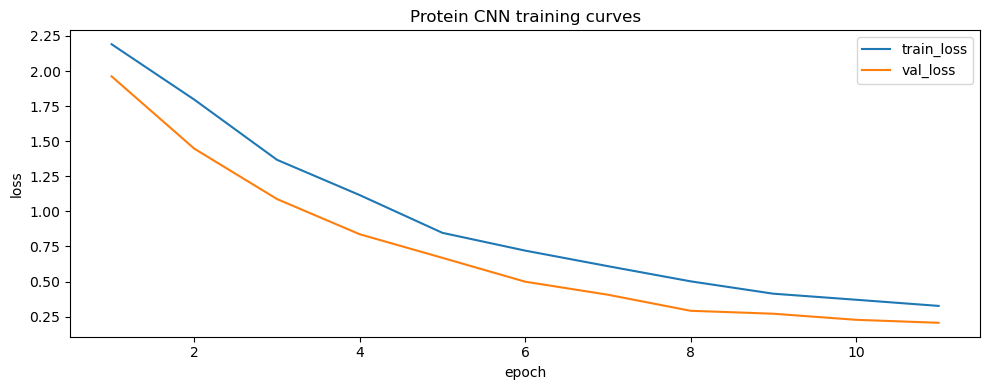

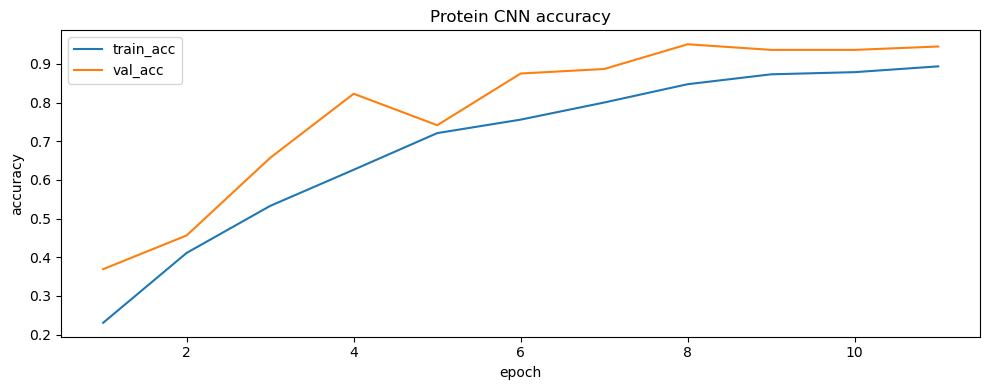

(PosixPath('/Users/saturnine/Projects/bio-seq-lm-capstone/reports/figures/protein_seq_cnn_loss_top10_per400.png'),
 PosixPath('/Users/saturnine/Projects/bio-seq-lm-capstone/reports/figures/protein_seq_cnn_acc_top10_per400.png'))

In [10]:
hist = pd.DataFrame(history)

loss_fig = FIGURES / "protein_seq_cnn_loss_top10_per400.png"
acc_fig  = FIGURES / "protein_seq_cnn_acc_top10_per400.png"

plt.figure(figsize=(10,4))
plt.plot(hist["epoch"], hist["train_loss"], label="train_loss")
plt.plot(hist["epoch"], hist["val_loss"], label="val_loss")
plt.title("Protein CNN training curves")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.tight_layout()
plt.savefig(loss_fig, dpi=200)
plt.show()

plt.figure(figsize=(10,4))
plt.plot(hist["epoch"], hist["train_acc"], label="train_acc")
plt.plot(hist["epoch"], hist["val_acc"], label="val_acc")
plt.title("Protein CNN accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.tight_layout()
plt.savefig(acc_fig, dpi=200)
plt.show()

loss_fig, acc_fig

## Test evaluation

We load the best checkpoint and evaluate on the test split.

Outputs:
- test metrics (accuracy, weighted precision/recall/F1)
- confusion matrix figure with **visible numbers (including zeros)**
- test results CSV and summary JSON

In [11]:
# Load best weights
model.load_state_dict(torch.load(best_path, map_location=DEVICE))
model.eval()
print("Loaded:", best_path)

y_true = []
y_pred = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        logits = model(xb)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        y_pred.extend(list(preds))
        y_true.extend(list(yb.numpy()))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

len(y_true), len(y_pred), MAX_LEN

Loaded: /Users/saturnine/Projects/bio-seq-lm-capstone/models/protein/sequence_cnn/cnn_top10_per400.pt


(344, 344, 512)

In [12]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

acc = float(accuracy_score(y_true, y_pred))
prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(
    y_true, y_pred, average="weighted", zero_division=0
)

metrics = {
    "accuracy": acc,
    "precision_weighted": float(prec_w),
    "recall_weighted": float(rec_w),
    "f1_weighted": float(f1_w),
    "n_test": int(len(y_true)),
    "n_classes": int(K),
    "max_len": int(MAX_LEN),
    "model": "sequence_cnn"
}
metrics

{'accuracy': 0.9244186046511628,
 'precision_weighted': 0.9263961692986353,
 'recall_weighted': 0.9244186046511628,
 'f1_weighted': 0.9236152393294279,
 'n_test': 344,
 'n_classes': 10,
 'max_len': 512,
 'model': 'sequence_cnn'}

In [13]:
test_out = pd.DataFrame([metrics])
test_csv = REPORTS / "protein_seq_cnn_test_results_top10_per400.csv"
test_out.to_csv(test_csv, index=False)
test_csv

PosixPath('/Users/saturnine/Projects/bio-seq-lm-capstone/reports/protein_seq_cnn_test_results_top10_per400.csv')

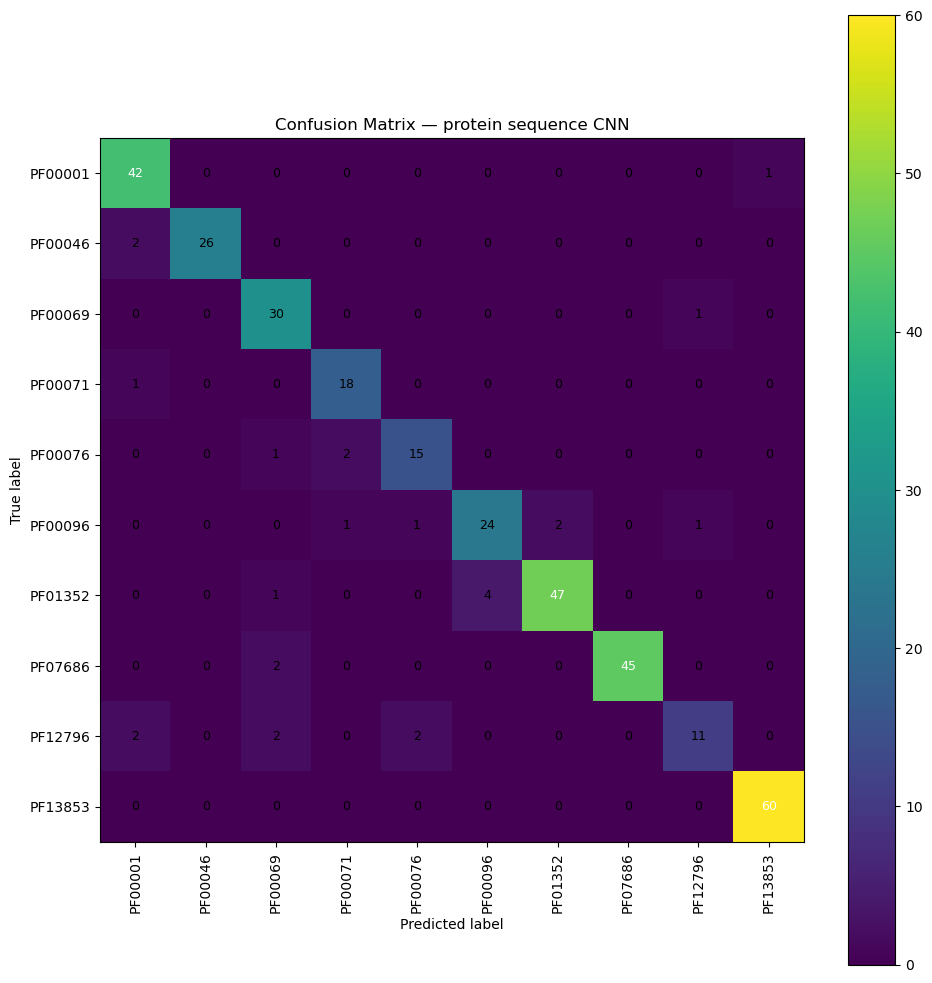

(array([[42,  0,  0,  0,  0,  0,  0,  0,  0,  1],
        [ 2, 26,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0, 30,  0,  0,  0,  0,  0,  1,  0],
        [ 1,  0,  0, 18,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  1,  2, 15,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  1,  1, 24,  2,  0,  1,  0],
        [ 0,  0,  1,  0,  0,  4, 47,  0,  0,  0],
        [ 0,  0,  2,  0,  0,  0,  0, 45,  0,  0],
        [ 2,  0,  2,  0,  2,  0,  0,  0, 11,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0, 60]]),
 PosixPath('/Users/saturnine/Projects/bio-seq-lm-capstone/reports/figures/cm_protein_seq_cnn_top10_per400.png'))

In [14]:
cm = confusion_matrix(y_true, y_pred, labels=list(range(K)))
cm_fig = FIGURES / "cm_protein_seq_cnn_top10_per400.png"

plt.figure(figsize=(10, 10))
im = plt.imshow(cm)
plt.title("Confusion Matrix — protein sequence CNN")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(ticks=np.arange(K), labels=classes, rotation=90)
plt.yticks(ticks=np.arange(K), labels=classes)
plt.colorbar(im)

# Annotate ALL cells and auto-switch text color for contrast
thresh = cm.max() / 2.0
for i in range(K):
    for j in range(K):
        val = cm[i, j]
        color = "white" if val > thresh else "black"
        plt.text(j, i, f"{val}", ha="center", va="center", color=color, fontsize=9)

plt.tight_layout()
plt.savefig(cm_fig, dpi=200)
plt.show()

cm, cm_fig

## Save run summary

We store:
- paths to artifacts
- configuration values
- test metrics
- label classes

In [15]:
summary = {
    "seed": int(SEED),
    "k_classes": int(K),
    "classes": list(classes),
    "max_len": int(MAX_LEN),
    "batch_size": int(BATCH_SIZE),
    "emb_dim": 32,
    "epochs_ran": int(len(history)),
    "best_val_acc": float(best_val_acc),
    "device": DEVICE,
    "paths": {
        "dataset": str(csv_path),
        "model": str(best_path),
        "loss_fig": str(loss_fig),
        "acc_fig": str(acc_fig),
        "cm_fig": str(cm_fig),
        "test_csv": str(test_csv),
    },
    "test_metrics": metrics,
}

summary_path = REPORTS / "protein_seq_cnn_summary_top10_per400.json"
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

summary_path

PosixPath('/Users/saturnine/Projects/bio-seq-lm-capstone/reports/protein_seq_cnn_summary_top10_per400.json')